Customer Behaviour and Churn Analysis

Chapter 1: Data setup and Loading

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
!{sys.executable} -m pip install jinja2
import warnings

warnings.filterwarnings('ignore')

# Chart style — makes everything look professional out of the box
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading the file

In [3]:
df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Basic Statistics and Data Types

In [4]:
print(df.dtypes)

print("\n─── Statistical Summary (numeric columns) ───")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

,count,mean,std,min,25%,50%,75%,max
Age,47505.000000,37.802968,11.834668,5.000000,29.000000,38.000000,46.000000,200.000000
Membership_Years,50000.000000,2.984009,2.059105,0.100000,1.400000,2.500000,4.000000,10.000000
Login_Frequency,50000.000000,11.624660,7.810657,0.000000,6.000000,11.000000,17.000000,46.000000
Session_Duration_Avg,46601.000000,27.660754,10.871013,1.000000,19.700000,26.800000,34.700000,75.600000
Pages_Per_Session,47000.000000,8.737811,3.778220,1.000000,6.000000,8.400000,11.200000,24.100000
Cart_Abandonment_Rate,50000.000000,57.079973,16.282723,0.000000,46.400000,58.100000,68.700000,143.743350
Wishlist_Items,46000.000000,4.298391,3.189754,0.000000,2.000000,4.000000,6.000000,28.000000
Total_Purchases,50000.000000,13.111576,7.017312,-13.000000,8.000000,12.000000,17.000000,128.700000
Average_Order_Value,50000.000000,123.117330,175.569714,26.380000,87.050000,112.970000,144.440000,9666.379178
Days_Since_Last_Purchase,47000.000000,29.792872,29.695062,0.000000,9.000000,21.000000,41.000000,287.000000


─── Target Variable Distribution ───
              Count  Percentage
Retained (0)  35550        71.1
Churned (1)   14450        28.9


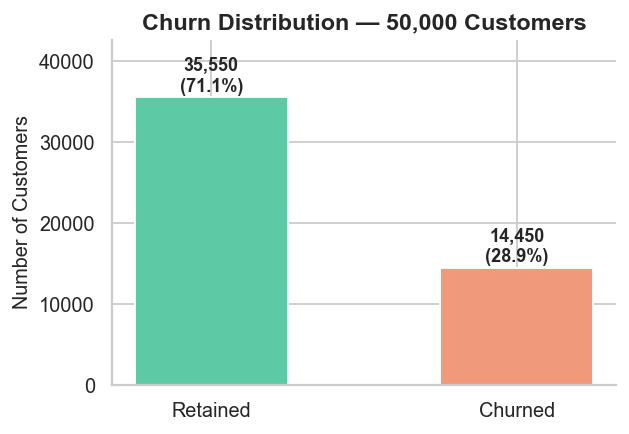

In [5]:
churn_counts = df['Churned'].value_counts()
churn_pct    = df['Churned'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count'      : churn_counts,
    'Percentage' : churn_pct.round(1)
})
summary.index = ['Retained (0)', 'Churned (1)']

print("─── Target Variable Distribution ───")
print(summary.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Retained', 'Churned'], churn_counts.values,
       color=['#5DCAA5', '#F0997B'], width=0.5, edgecolor='white')

for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    ax.text(i, val + 200, f"{val:,}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Churn Distribution — 50,000 Customers")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.show()

Chapter 2: Data Cleaning & Quality Audit

Columns with missing data: 14 out of 25

                               Missing Count  Missing %
Social_Media_Engagement_Score           6000       12.0
Credit_Balance                          5500       11.0
Mobile_App_Usage                        5000       10.0
Returns_Rate                            4491        9.0
Wishlist_Items                          4000        8.0
Discount_Usage_Rate                     3500        7.0
Product_Reviews_Written                 3500        7.0
Session_Duration_Avg                    3399        6.8
Pages_Per_Session                       3000        6.0
Days_Since_Last_Purchase                3000        6.0
Email_Open_Rate                         2528        5.1
Age                                     2495        5.0
Payment_Method_Diversity                2500        5.0
Customer_Service_Calls                   168        0.3


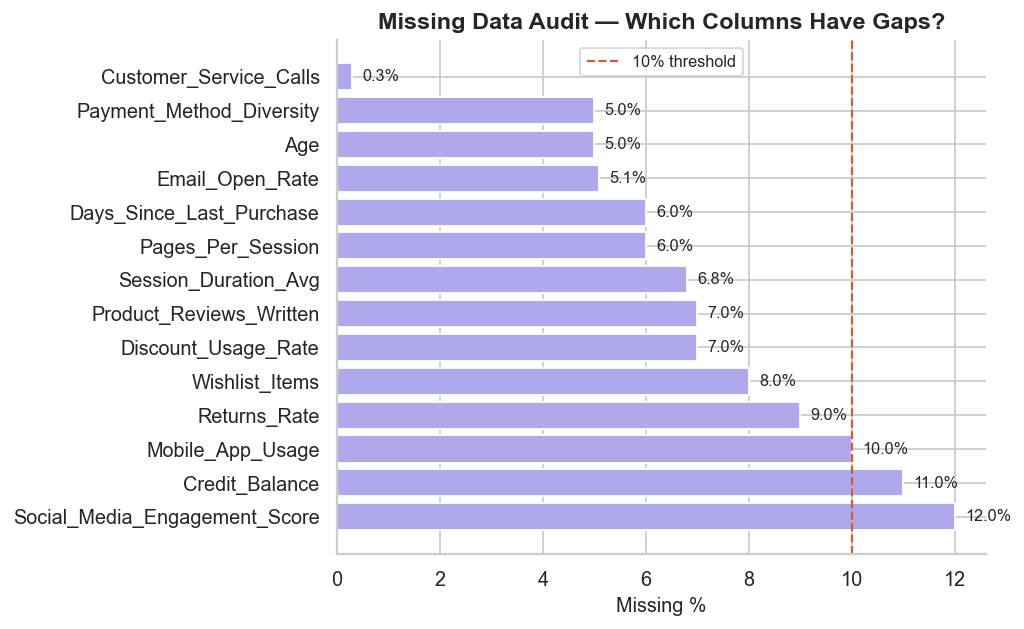

In [6]:
# ── Chapter 2: Data Cleaning & Quality Audit ─────────────────────────────────

# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(1)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing data: {len(missing)} out of {df.shape[1]}\n")
print(missing.to_string())

# Visual
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing.index, missing['Missing %'], color='#AFA9EC', edgecolor='white')
ax.axvline(x=10, color='#D85A30', linestyle='--', linewidth=1.2, label='10% threshold')
ax.set_xlabel("Missing %")
ax.set_title("Missing Data Audit — Which Columns Have Gaps?")
ax.legend(fontsize=9)
for i, val in enumerate(missing['Missing %']):
    ax.text(val + 0.2, i, f"{val}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"Duplicate rows removed : {before - after}")
print(f"Rows remaining         : {after:,}")

Duplicate rows removed : 0
Rows remaining         : 50,000


In [8]:
# Age has a max of 200 — clearly a data entry error
print("─── Age outlier check ───")
print(df['Age'].describe().round(1))
print(f"\nRows where Age > 100 : {(df['Age'] > 100).sum()}")

# Cap age at 100 (we keep the rows, just fix the value)
df.loc[df['Age'] > 100, 'Age'] = np.nan   # treat as missing, not corrupt data
print(f"\nOutlier ages replaced with NaN ✅")

─── Age outlier check ───
count    47505.0
mean        37.8
std         11.8
min          5.0
25%         29.0
50%         38.0
75%         46.0
max        200.0
Name: Age, dtype: float64

Rows where Age > 100 : 20

Outlier ages replaced with NaN ✅


In [9]:
print("─── Total Purchases check ───")
print(f"Min value            : {df['Total_Purchases'].min()}")
print(f"Negative rows        : {(df['Total_Purchases'] < 0).sum()}")

# Negative purchases make no business sense — clip to 0
df['Total_Purchases'] = df['Total_Purchases'].clip(lower=0)
print(f"\nNegative values clipped to 0 ✅")

─── Total Purchases check ───
Min value            : -13.0
Negative rows        : 40

Negative values clipped to 0 ✅


In [10]:
# Strategy:
#   Numerical columns  → fill with MEDIAN  (robust to skew)
#   No categorical cols have missing values in this dataset

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Churned')   # never impute the target variable

missing_before = df[numerical_cols].isnull().sum().sum()

for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

missing_after = df[numerical_cols].isnull().sum().sum()

print(f"Missing values before imputation : {missing_before:,}")
print(f"Missing values after imputation  : {missing_after:,}")
print("\nImputation complete ✅")

Missing values before imputation : 49,101
Missing values after imputation  : 0

Imputation complete ✅


In [11]:
print("─── Cleaned Dataset Summary ───────────────────")
print(f"Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values    : {df.isnull().sum().sum()}")
print(f"Duplicate rows    : {df.duplicated().sum()}")
print(f"Churn rate        : {df['Churned'].mean()*100:.1f}%")
print(f"\n✅ Data is clean and ready for analysis")

# Save a clean copy so you never have to re-run cleaning again
df.to_csv("churn_cleaned.csv", index=False)
print("💾 Saved as churn_cleaned.csv")

─── Cleaned Dataset Summary ───────────────────
Shape             : 50,000 rows × 25 columns
Missing values    : 0
Duplicate rows    : 0
Churn rate        : 28.9%

✅ Data is clean and ready for analysis
💾 Saved as churn_cleaned.csv


Chater 3: Exploratory Data Analysis (EDA)

In [12]:


df = pd.read_csv("churn_cleaned.csv")
print(f"Loaded clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded clean dataset: 50,000 rows × 25 columns


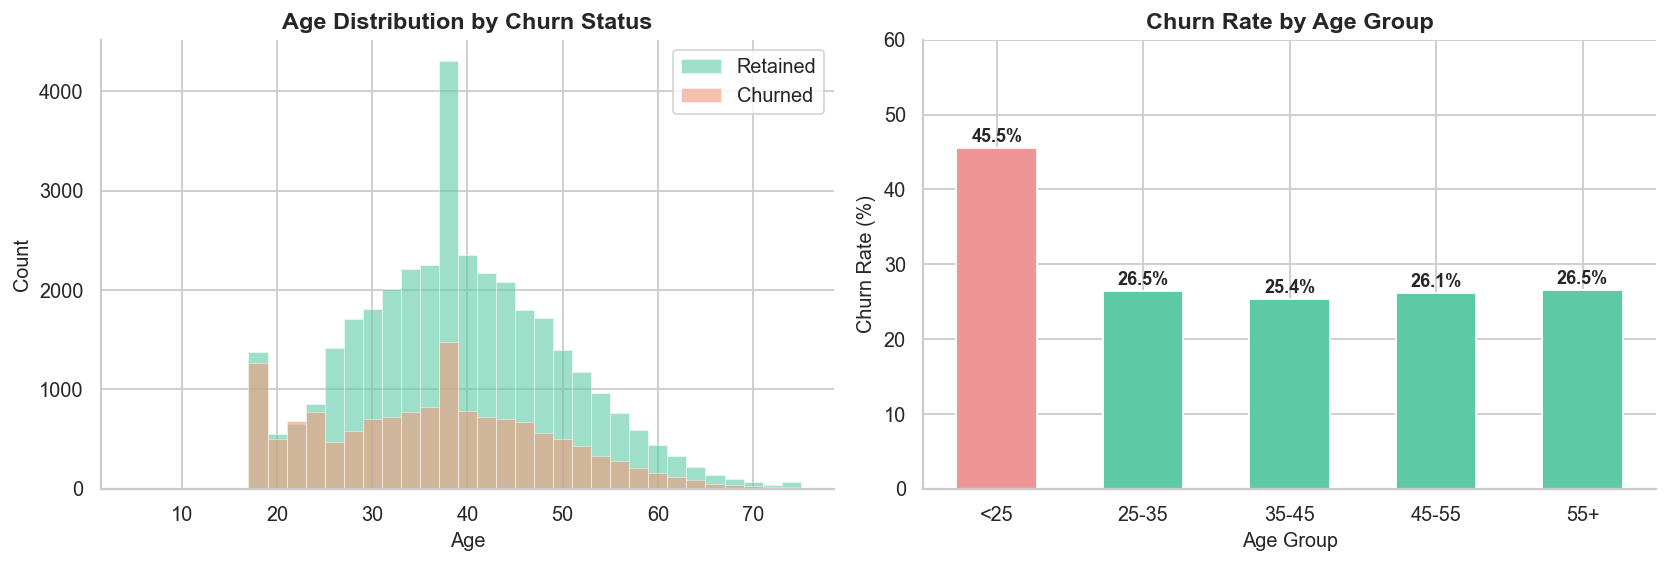

Key finding: Under-25s churn at nearly double the rate of all other age groups.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Histogram overlaid
for label, color in zip([0, 1], ['#5DCAA5', '#F0997B']):
    subset = df[df['Churned'] == label]['Age'].dropna()
    axes[0].hist(subset, bins=35, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned',
                 edgecolor='white', linewidth=0.4)
axes[0].set_title("Age Distribution by Churn Status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: Age group churn rate
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55+'])
age_churn = df.groupby('Age_Group', observed=True)['Churned'].mean() * 100

bars = axes[1].bar(age_churn.index, age_churn.values,
                   color=['#F09595' if v > 35 else '#5DCAA5' for v in age_churn.values],
                   edgecolor='white', width=0.55)
axes[1].set_title("Churn Rate by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 60)

for bar, val in zip(bars, age_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key finding: Under-25s churn at nearly double the rate of all other age groups.")

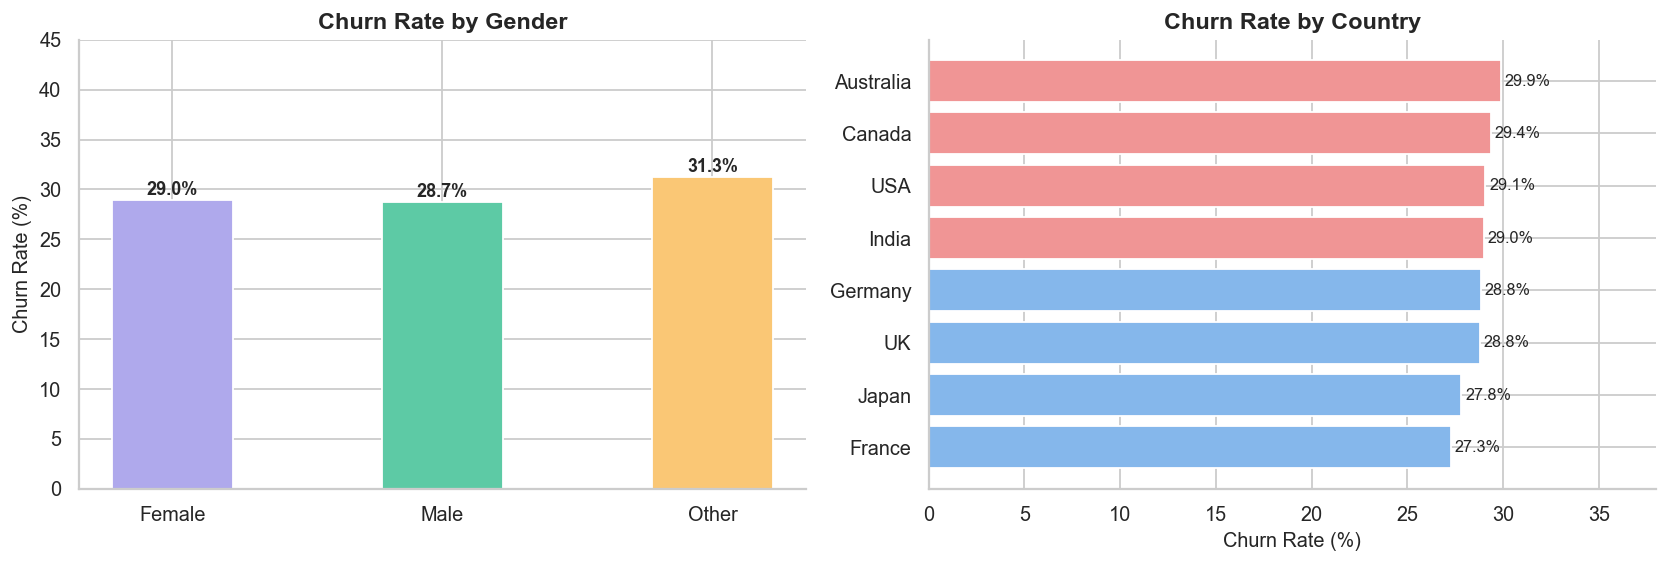

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Gender
gender_churn = df.groupby('Gender')['Churned'].mean() * 100
axes[0].bar(gender_churn.index, gender_churn.values,
            color=['#AFA9EC', '#5DCAA5', '#FAC775'], edgecolor='white', width=0.45)
axes[0].set_title("Churn Rate by Gender")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 45)
for i, val in enumerate(gender_churn.values):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha='center', fontweight='bold', fontsize=10)

# Right: Country
country_churn = df.groupby('Country')['Churned'].mean().sort_values(ascending=True) * 100
colors = ['#F09595' if v > 29 else '#85B7EB' for v in country_churn.values]
axes[1].barh(country_churn.index, country_churn.values, color=colors, edgecolor='white')
axes[1].set_title("Churn Rate by Country")
axes[1].set_xlabel("Churn Rate (%)")
axes[1].set_xlim(0, 38)
for i, val in enumerate(country_churn.values):
    axes[1].text(val + 0.2, i, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

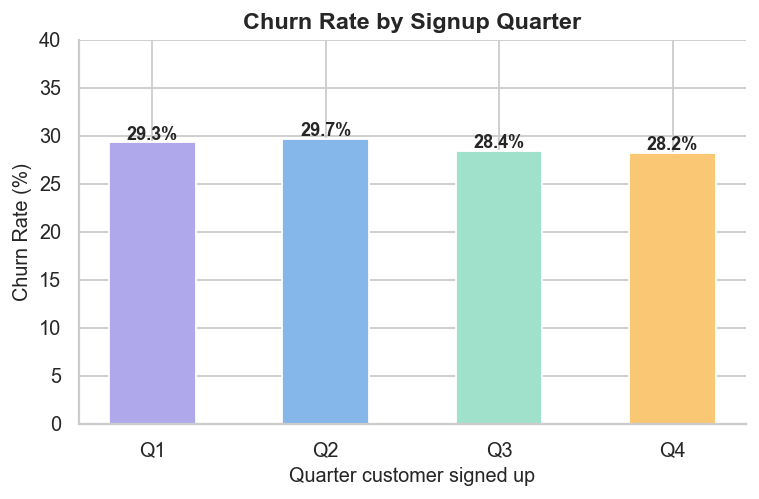

In [15]:
quarter_churn = df.groupby('Signup_Quarter')['Churned'].mean().sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(quarter_churn.index, quarter_churn.values,
              color=['#AFA9EC', '#85B7EB', '#9FE1CB', '#FAC775'],
              edgecolor='white', width=0.5)
ax.set_title("Churn Rate by Signup Quarter")
ax.set_xlabel("Quarter customer signed up")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 40)

for bar, val in zip(bars, quarter_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

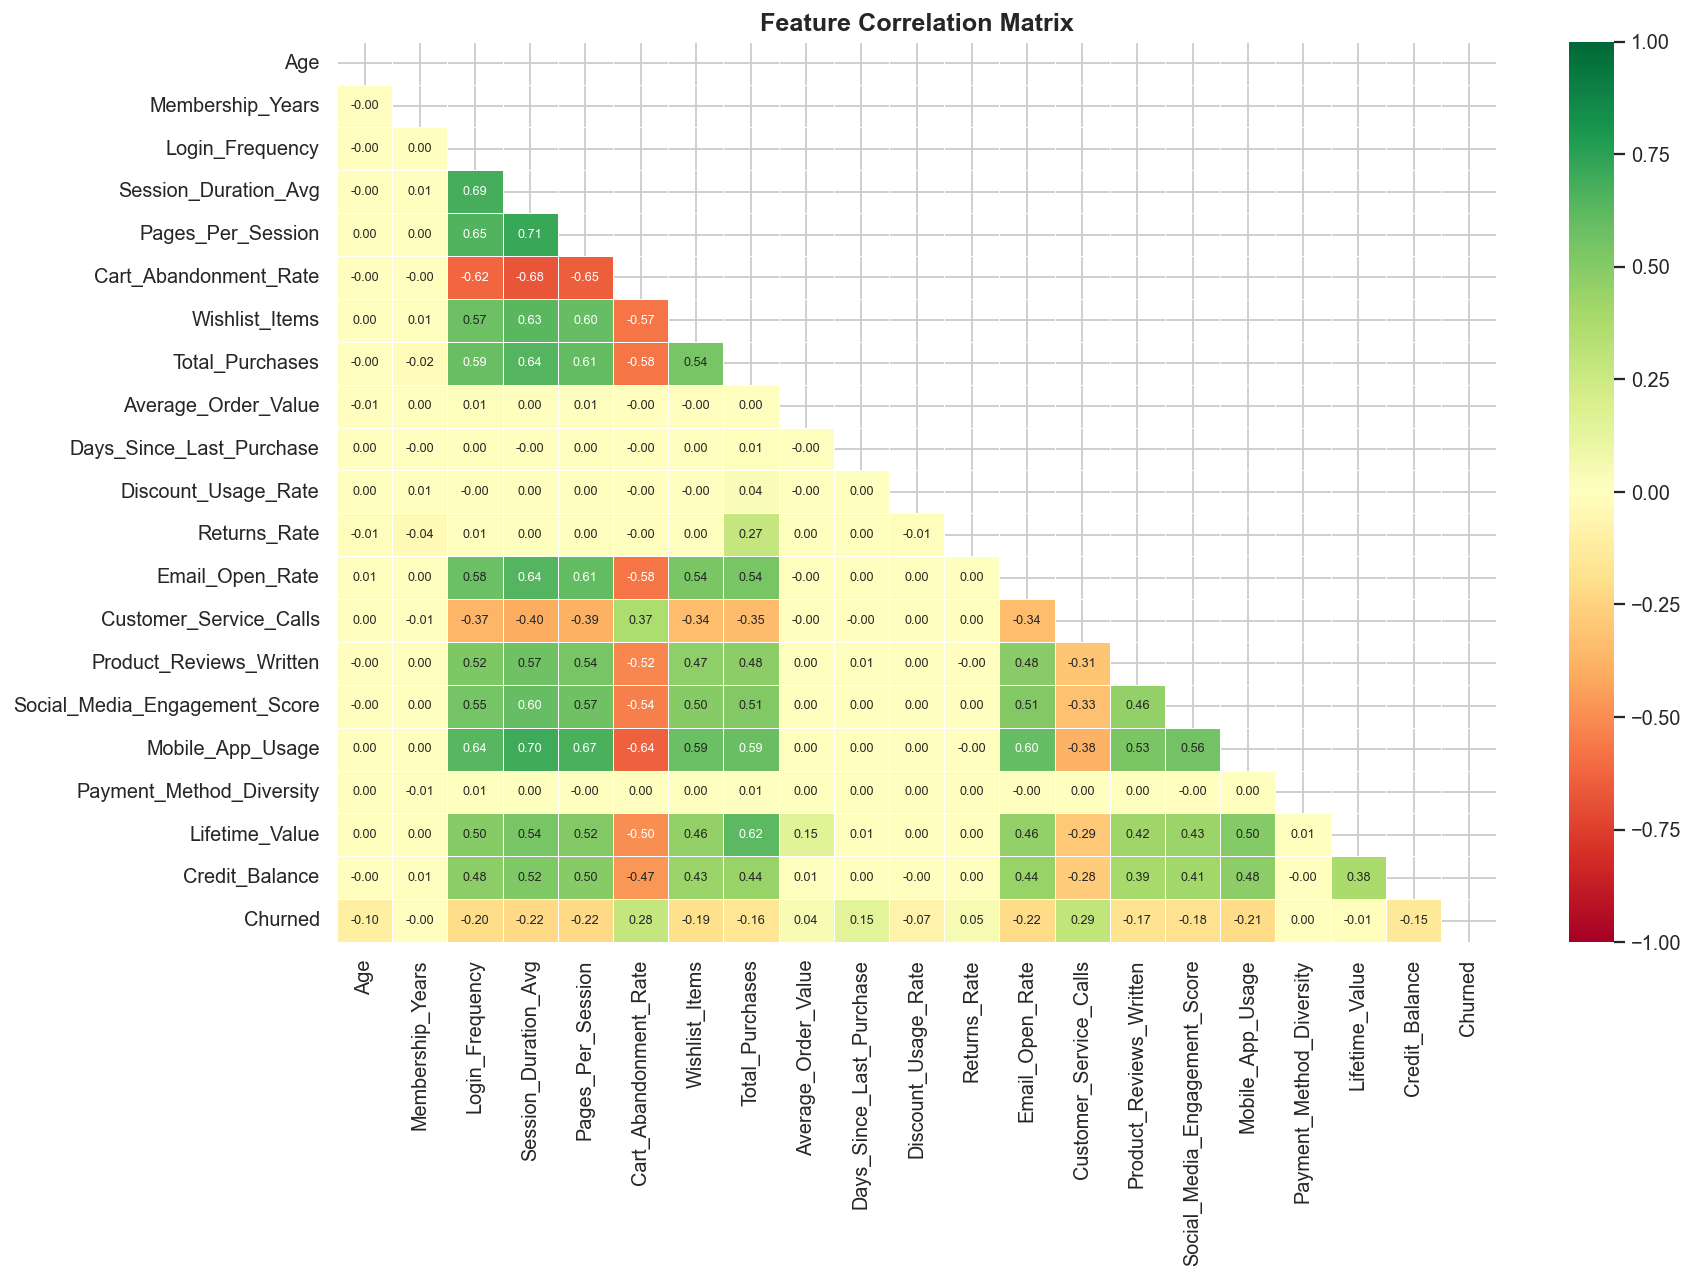

─── Top correlations with Churned (strongest first) ───
Customer_Service_Calls           0.290
Cart_Abandonment_Rate            0.278
Pages_Per_Session                0.225
Session_Duration_Avg             0.220
Email_Open_Rate                  0.216
Mobile_App_Usage                 0.211
Login_Frequency                  0.204
Wishlist_Items                   0.190
Social_Media_Engagement_Score    0.180
Product_Reviews_Written          0.174


In [16]:
# Shows which features are related to each other — important before modelling
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with Churned specifically
print("─── Top correlations with Churned (strongest first) ───")
churn_corr = corr_matrix['Churned'].drop('Churned').abs().sort_values(ascending=False)
print(churn_corr.head(10).round(3).to_string())

Chapter 5 : Behavioral Analysis | Churned vs Retained

In [17]:
df = pd.read_csv("churn_cleaned.csv")

# Split into two groups — we'll compare them throughout this chapter
retained = df[df['Churned'] == 0]
churned  = df[df['Churned'] == 1]

print(f"Retained customers : {len(retained):,}")
print(f"Churned customers  : {len(churned):,}")

Retained customers : 35,550
Churned customers  : 14,450


In [18]:
behavior_cols = [
    'Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Cart_Abandonment_Rate',
    'Days_Since_Last_Purchase',
    'Email_Open_Rate',
    'Customer_Service_Calls',
    'Mobile_App_Usage',
    'Social_Media_Engagement_Score',
    'Product_Reviews_Written',
    'Total_Purchases',
    'Average_Order_Value',
]

comparison = pd.DataFrame({
    'Retained Avg' : retained[behavior_cols].mean(),
    'Churned Avg'  : churned[behavior_cols].mean(),
})

comparison['Difference %'] = (
    (comparison['Churned Avg'] - comparison['Retained Avg'])
    / comparison['Retained Avg'] * 100
).round(1)

comparison = comparison.round(2)
comparison['Direction'] = comparison['Difference %'].apply(
    lambda x: '▲ Churned higher' if x > 0 else '▼ Churned lower'
)

print("─── Behavioral Comparison: Churned vs Retained ───────────────────────")
print(comparison.to_string())

─── Behavioral Comparison: Churned vs Retained ───────────────────────
                               Retained Avg  Churned Avg  Difference %         Direction
Login_Frequency                       12.64         9.12         -27.9   ▼ Churned lower
Session_Duration_Avg                  29.07        23.99         -17.5   ▼ Churned lower
Pages_Per_Session                      9.24         7.43         -19.7   ▼ Churned lower
Cart_Abandonment_Rate                 54.19        64.18          18.4  ▲ Churned higher
Days_Since_Last_Purchase              26.54        35.97          35.5  ▲ Churned higher
Email_Open_Rate                       22.79        16.16         -29.1   ▼ Churned lower
Customer_Service_Calls                 5.18         6.90          33.0  ▲ Churned higher
Mobile_App_Usage                      20.50        16.33         -20.3   ▼ Churned lower
Social_Media_Engagement_Score         31.37        23.71         -24.4   ▼ Churned lower
Product_Reviews_Written                

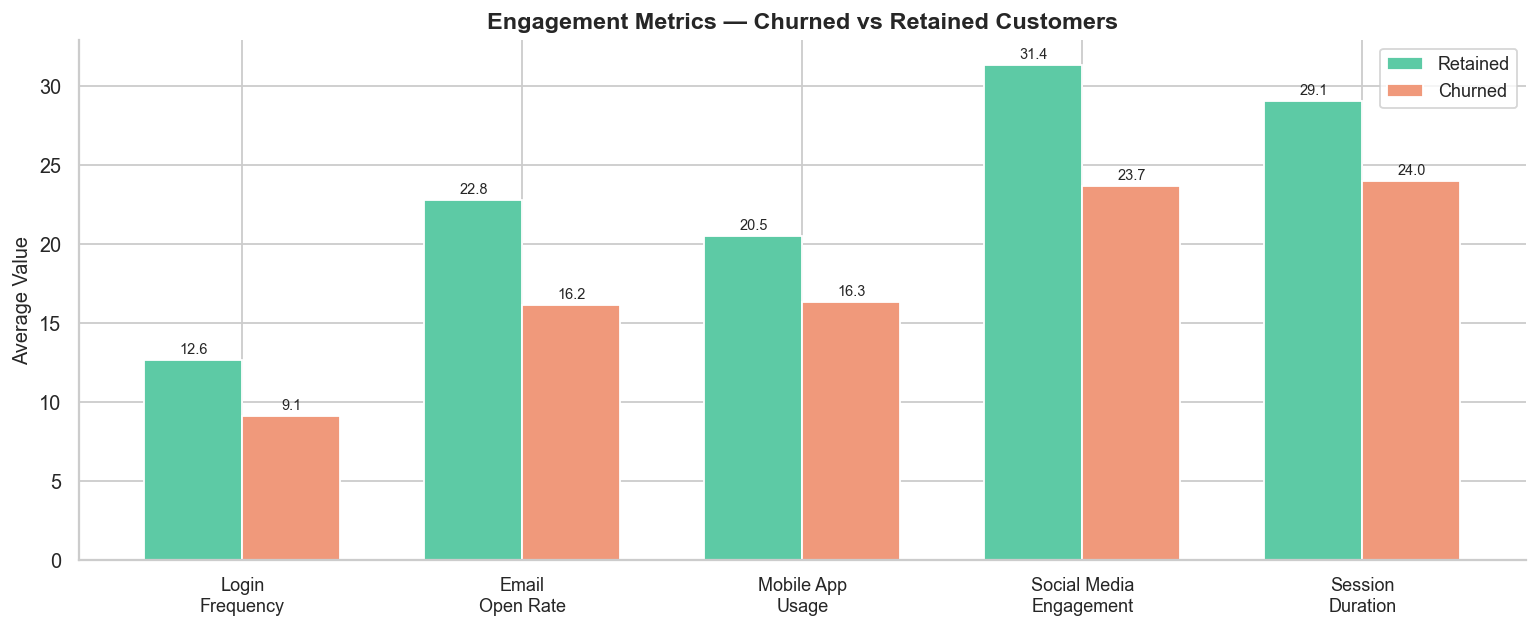

Key finding: Churned customers are disengaged across EVERY channel —
lower login, lower email opens, lower app usage, lower social engagement.


In [19]:
# Metrics where LOWER = more likely to churn
engagement_metrics = {
    'Login\nFrequency'        : ('Login_Frequency',                -27.8),
    'Email\nOpen Rate'        : ('Email_Open_Rate',                -30.7),
    'Mobile App\nUsage'       : ('Mobile_App_Usage',               -22.4),
    'Social Media\nEngagement': ('Social_Media_Engagement_Score',  -27.3),
    'Session\nDuration'       : ('Session_Duration_Avg',           -18.9),
}

labels   = list(engagement_metrics.keys())
retained_vals = [retained[v[0]].mean() for v in engagement_metrics.values()]
churned_vals  = [churned[v[0]].mean()  for v in engagement_metrics.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, retained_vals, width, label='Retained',
               color='#5DCAA5', edgecolor='white')
bars2 = ax.bar(x + width/2, churned_vals,  width, label='Churned',
               color='#F0997B', edgecolor='white')

ax.set_title("Engagement Metrics — Churned vs Retained Customers", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Average Value")
ax.legend(fontsize=10)

# Annotate each bar with its value
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Key finding: Churned customers are disengaged across EVERY channel —")
print("lower login, lower email opens, lower app usage, lower social engagement.")

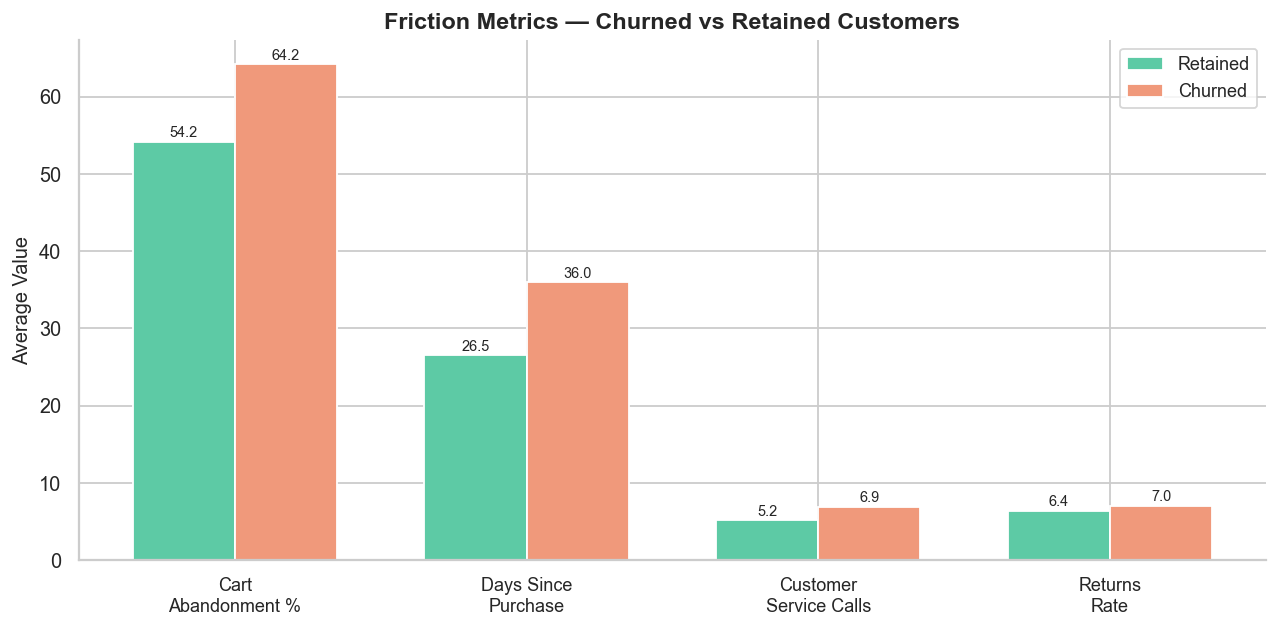

Key finding: Churned customers called support 33% more and abandoned
carts 18% more — clear signs of friction before they left.


In [22]:
# Metrics where HIGHER = more likely to churn
friction_metrics = {
    'Cart\nAbandonment %' : 'Cart_Abandonment_Rate',
    'Days Since\nPurchase' : 'Days_Since_Last_Purchase',
    'Customer\nService Calls' : 'Customer_Service_Calls',
    'Returns\nRate' : 'Returns_Rate',
}

labels        = list(friction_metrics.keys())
retained_vals = [retained[v].mean() for v in friction_metrics.values()]
churned_vals  = [churned[v].mean()  for v in friction_metrics.values()]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, retained_vals, width, label='Retained',
               color='#5DCAA5', edgecolor='white')
bars2 = ax.bar(x + width/2, churned_vals,  width, label='Churned',
               color='#F0997B', edgecolor='white')

ax.set_title("Friction Metrics — Churned vs Retained Customers", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Average Value")
ax.legend(fontsize=10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Key finding: Churned customers called support 33% more and abandoned")
print("carts 18% more — clear signs of friction before they left.")

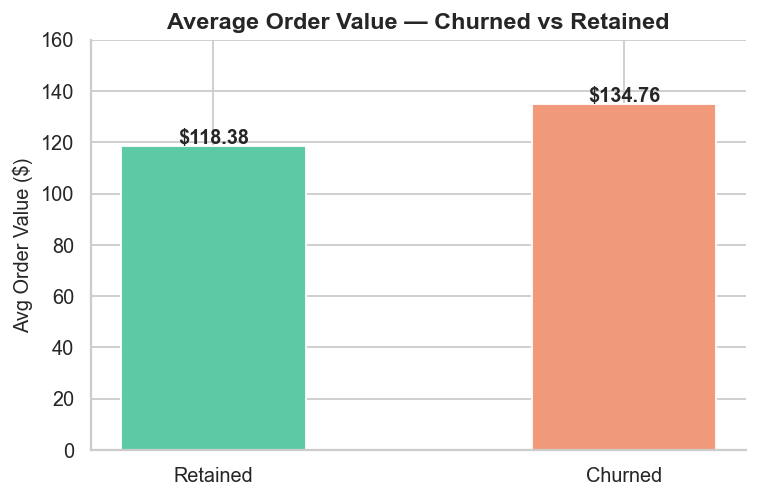

Churned customers spent 13.8% MORE per order than retained ones.
This means churned customers were NOT low-value shoppers.
They were high-spenders who experienced friction and left.
→ Business implication: Winback campaigns for this segment have strong ROI.


In [23]:
# Churned customers actually spent MORE per order — important nuance
fig, ax = plt.subplots(figsize=(6, 4))

aov_data = [retained['Average_Order_Value'].mean(),
            churned['Average_Order_Value'].mean()]
labels   = ['Retained', 'Churned']
colors   = ['#5DCAA5', '#F0997B']

bars = ax.bar(labels, aov_data, color=colors, edgecolor='white', width=0.45)
ax.set_title("Average Order Value — Churned vs Retained")
ax.set_ylabel("Avg Order Value ($)")
ax.set_ylim(0, 160)

for bar, val in zip(bars, aov_data):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"${val:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

diff = ((aov_data[1] - aov_data[0]) / aov_data[0]) * 100
print(f"Churned customers spent {diff:.1f}% MORE per order than retained ones.")
print("This means churned customers were NOT low-value shoppers.")
print("They were high-spenders who experienced friction and left.")
print("→ Business implication: Winback campaigns for this segment have strong ROI.")

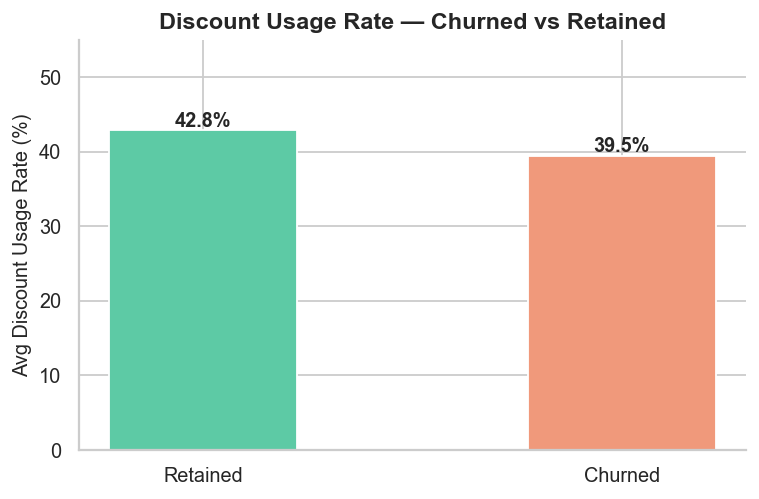

Key finding: Retained customers actually used MORE discounts than churned ones.
Discounts alone do not cause retention — engagement does.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

disc_data = [retained['Discount_Usage_Rate'].mean(),
             churned['Discount_Usage_Rate'].mean()]

bars = ax.bar(['Retained', 'Churned'], disc_data,
              color=['#5DCAA5', '#F0997B'], edgecolor='white', width=0.45)
ax.set_title("Discount Usage Rate — Churned vs Retained")
ax.set_ylabel("Avg Discount Usage Rate (%)")
ax.set_ylim(0, 55)

for bar, val in zip(bars, disc_data):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key finding: Retained customers actually used MORE discounts than churned ones.")
print("Discounts alone do not cause retention, engagement does.")

Chapter 5: Customer Segmentation

In [ ]:
df = pd.read_csv("churn_cleaned.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows")
print("\nWe will build 3 segmentation systems:")
print("  1. LTV Segments     — who is most valuable?")
print("  2. Engagement Score — who is most engaged?")
print("  3. At-Risk Flag     — who is about to leave?")

Dataset loaded: 50,000 rows

We will build 3 segmentation systems:
  1. LTV Segments     — who is most valuable?
  2. Engagement Score — who is most engaged?
  3. At-Risk Flag     — who is about to leave?


─── LTV Segment Summary ────────────────────────────────────
             Customer_Count  Churn_Rate_pct  Avg_LTV  Avg_Orders  Avg_Service_Calls
LTV_Segment                                                                        
Low                   12500            41.3    532.0         7.3               6.74
Mid                   12500            20.3   1010.0        11.5               6.00
High                  12500            14.4   1530.0        14.7               5.38
Premium               12500            39.6   2691.0        19.0               4.61


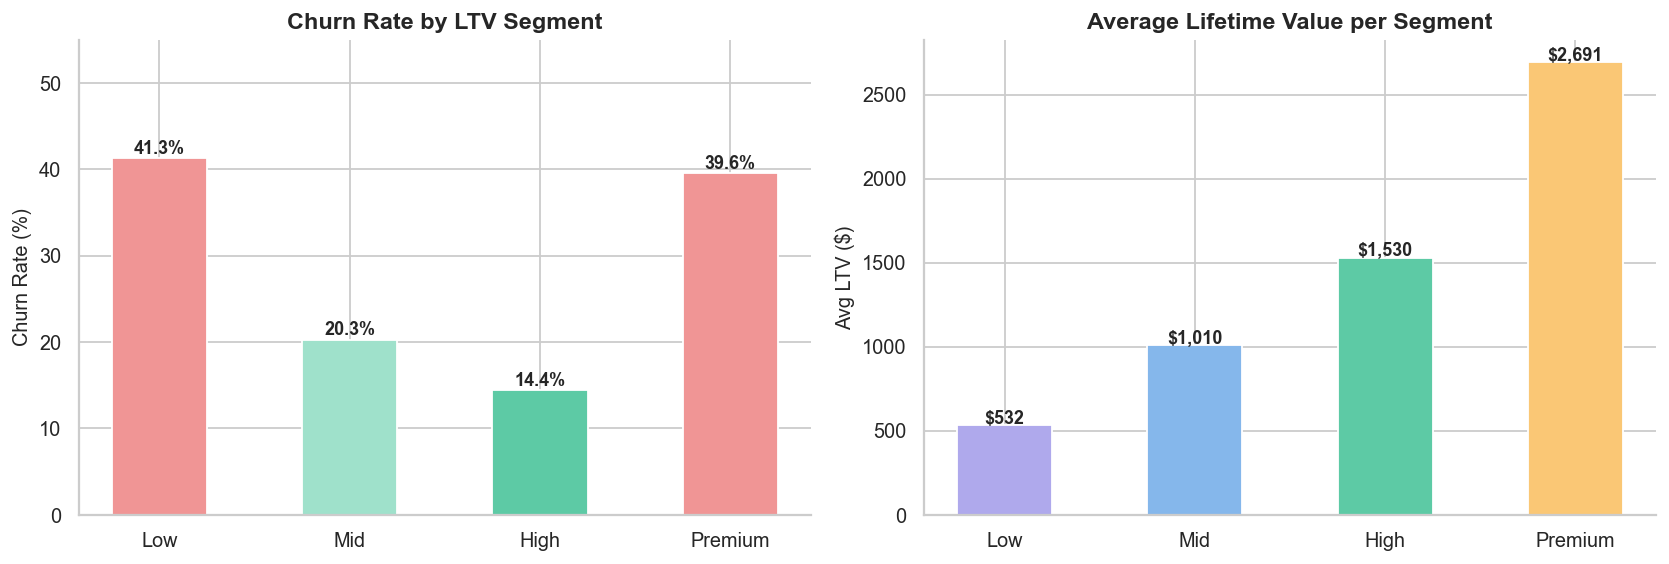


Key finding: BOTH Low and Premium tiers churn at ~40%.
Low tier  → never found value in the product.
Premium tier → found better alternatives elsewhere.
This U-shaped pattern means you need TWO different retention strategies.


In [26]:
# Split customers into 4 equal-sized buckets based on Lifetime Value
df['LTV_Segment'] = pd.qcut(
    df['Lifetime_Value'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Premium']
)

# Summary table per LTV tier
ltv_summary = df.groupby('LTV_Segment', observed=True).agg(
    Customer_Count       = ('Churned', 'count'),
    Churn_Rate_pct       = ('Churned', lambda x: round(x.mean() * 100, 1)),
    Avg_LTV              = ('Lifetime_Value', lambda x: round(x.mean(), 0)),
    Avg_Orders           = ('Total_Purchases', lambda x: round(x.mean(), 1)),
    Avg_Service_Calls    = ('Customer_Service_Calls', lambda x: round(x.mean(), 2)),
)

print("─── LTV Segment Summary ────────────────────────────────────")
print(ltv_summary.to_string())

# Visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — churn rate by LTV
colors = ['#F09595', '#9FE1CB', '#5DCAA5', '#F09595']  # low & premium both red
bars = axes[0].bar(ltv_summary.index, ltv_summary['Churn_Rate_pct'],
                   color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Churn Rate by LTV Segment")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 55)
for bar, val in zip(bars, ltv_summary['Churn_Rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

# Right — avg LTV per segment
bars2 = axes[1].bar(ltv_summary.index, ltv_summary['Avg_LTV'],
                    color=['#AFA9EC','#85B7EB','#5DCAA5','#FAC775'],
                    edgecolor='white', width=0.5)
axes[1].set_title("Average Lifetime Value per Segment")
axes[1].set_ylabel("Avg LTV ($)")
for bar, val in zip(bars2, ltv_summary['Avg_LTV']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f"${val:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey finding: BOTH Low and Premium tiers churn at ~40%.")
print("Low tier  → never found value in the product.")
print("Premium tier → found better alternatives elsewhere.")
print("This U-shaped pattern means you need TWO different retention strategies.")

In [27]:
# We build a single score from 5 engagement signals
# Each signal is normalised to 0–1, then averaged → final score 0–1

signals = [
    'Login_Frequency',
    'Email_Open_Rate',
    'Mobile_App_Usage',
    'Social_Media_Engagement_Score',
    'Product_Reviews_Written',
]

# Normalise each signal between 0 and 1
for col in signals:
    col_min = df[col].min()
    col_max = df[col].max()
    df[f'{col}_norm'] = (df[col] - col_min) / (col_max - col_min)

# Average the normalised signals into one score
norm_cols = [f'{col}_norm' for col in signals]
df['Engagement_Score'] = df[norm_cols].mean(axis=1).round(4)

# Drop the temp normalised columns — keep the notebook clean
df.drop(columns=norm_cols, inplace=True)

# Bucket into engagement tiers
df['Engagement_Tier'] = pd.qcut(
    df['Engagement_Score'],
    q=4,
    labels=['Disengaged', 'Low', 'Medium', 'Highly Engaged']
)

print("─── Engagement Score Distribution ───")
print(df['Engagement_Score'].describe().round(3))

# Summary table
eng_summary = df.groupby('Engagement_Tier', observed=True).agg(
    Count       = ('Churned', 'count'),
    Churn_Rate  = ('Churned', lambda x: round(x.mean() * 100, 1)),
    Avg_Score   = ('Engagement_Score', lambda x: round(x.mean(), 3)),
    Avg_LTV     = ('Lifetime_Value', lambda x: round(x.mean(), 0)),
)

print("\n─── Engagement Tier Summary ────────────────────────────")
print(eng_summary.to_string())

─── Engagement Score Distribution ───
count    50000.000
mean         0.243
std          0.123
min          0.000
25%          0.150
50%          0.226
75%          0.320
max          0.795
Name: Engagement_Score, dtype: float64

─── Engagement Tier Summary ────────────────────────────
                 Count  Churn_Rate  Avg_Score  Avg_LTV
Engagement_Tier                                       
Disengaged       12514        51.8      0.103    845.0
Low              12499        24.2      0.187   1182.0
Medium           12495        20.4      0.270   1553.0
Highly Engaged   12492        19.2      0.413   2184.0


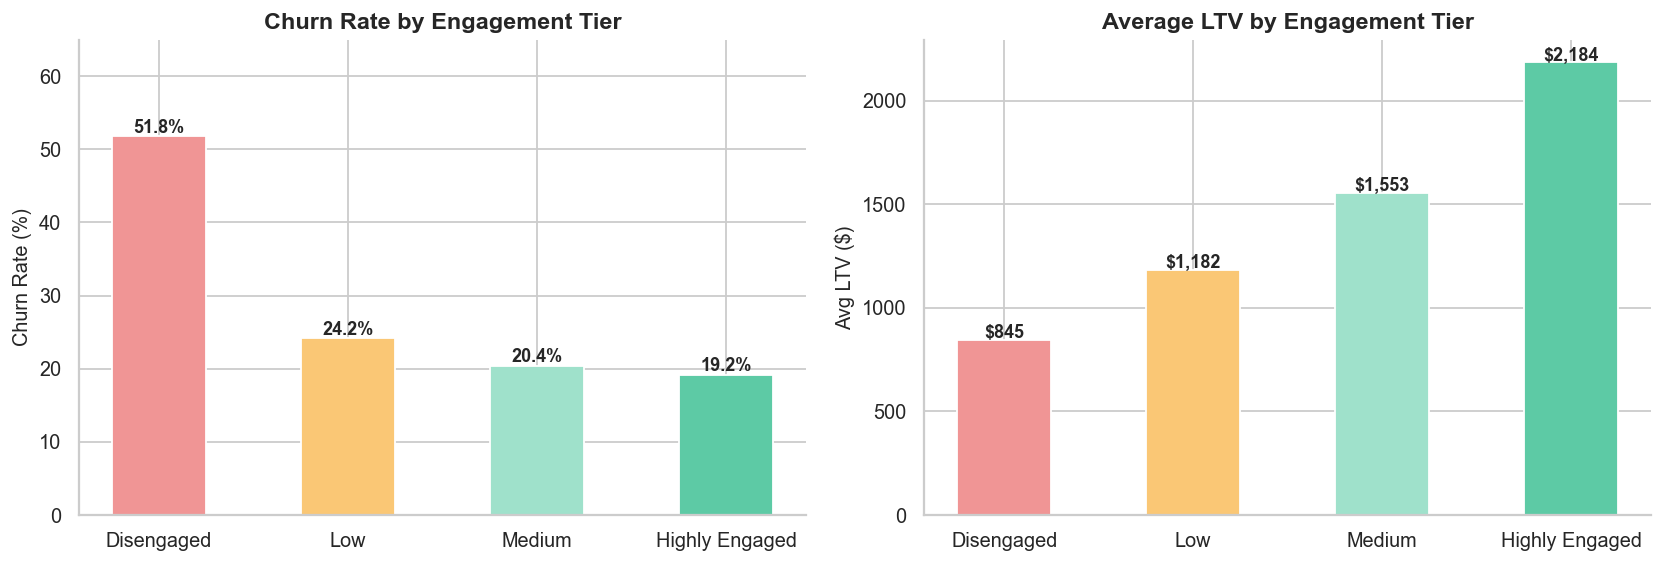


Key finding: Disengaged customers churn at 51.6% — more than 2.5x the
rate of Highly Engaged customers (19.4%). Engagement is the #1 retention lever.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

tier_colors = ['#F09595', '#FAC775', '#9FE1CB', '#5DCAA5']

# Left — churn rate by engagement tier
bars = axes[0].bar(eng_summary.index, eng_summary['Churn_Rate'],
                   color=tier_colors, edgecolor='white', width=0.5)
axes[0].set_title("Churn Rate by Engagement Tier")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 65)
for bar, val in zip(bars, eng_summary['Churn_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

# Right — avg LTV by engagement tier
bars2 = axes[1].bar(eng_summary.index, eng_summary['Avg_LTV'],
                    color=tier_colors, edgecolor='white', width=0.5)
axes[1].set_title("Average LTV by Engagement Tier")
axes[1].set_ylabel("Avg LTV ($)")
for bar, val in zip(bars2, eng_summary['Avg_LTV']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f"${val:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey finding: Disengaged customers churn at 51.6% — more than 2.5x the")
print("rate of Highly Engaged customers (19.4%). Engagement is the #1 retention lever.")

In [30]:
# At-risk = customers showing all 3 early warning signs simultaneously:
#   1. Cart abandonment in top 25%    → friction at checkout
#   2. Login frequency in bottom 25%  → pulling away from the product
#   3. Days since purchase in top 25% → purchase drop-off already happening

cart_threshold    = df['Cart_Abandonment_Rate'].quantile(0.75)
login_threshold   = df['Login_Frequency'].quantile(0.25)
recency_threshold = df['Days_Since_Last_Purchase'].quantile(0.75)

df['At_Risk'] = (
    (df['Cart_Abandonment_Rate']    > cart_threshold)    &
    (df['Login_Frequency']          < login_threshold)   &
    (df['Days_Since_Last_Purchase'] > recency_threshold)
)

at_risk_count    = df['At_Risk'].sum()
at_risk_churn    = df[df['At_Risk']]['Churned'].mean() * 100
baseline_churn   = df['Churned'].mean() * 100
not_risk_churn   = df[~df['At_Risk']]['Churned'].mean() * 100

print(f"─── At-Risk Segment Summary ──────────────────────────")
print(f"Customers flagged as at-risk  : {at_risk_count:,}")
print(f"% of total customer base      : {at_risk_count/len(df)*100:.1f}%")
print(f"Churn rate — at-risk segment  : {at_risk_churn:.1f}%")
print(f"Churn rate — not at-risk      : {not_risk_churn:.1f}%")
print(f"Churn rate — overall baseline : {baseline_churn:.1f}%")
print(f"\nLift over baseline            : {at_risk_churn/baseline_churn:.1f}x")
print(f"\n→ Flagging just {at_risk_count:,} customers identifies a group")
print(f"  that churns at {at_risk_churn:.0f}% vs {baseline_churn:.0f}% baseline.")
print(f"  That is a {at_risk_churn/baseline_churn:.1f}x improvement in targeting precision.")

─── At-Risk Segment Summary ──────────────────────────
Customers flagged as at-risk  : 1,530
% of total customer base      : 3.1%
Churn rate — at-risk segment  : 82.9%
Churn rate — not at-risk      : 27.2%
Churn rate — overall baseline : 28.9%

Lift over baseline            : 2.9x

→ Flagging just 1,530 customers identifies a group
  that churns at 83% vs 29% baseline.
  That is a 2.9x improvement in targeting precision.


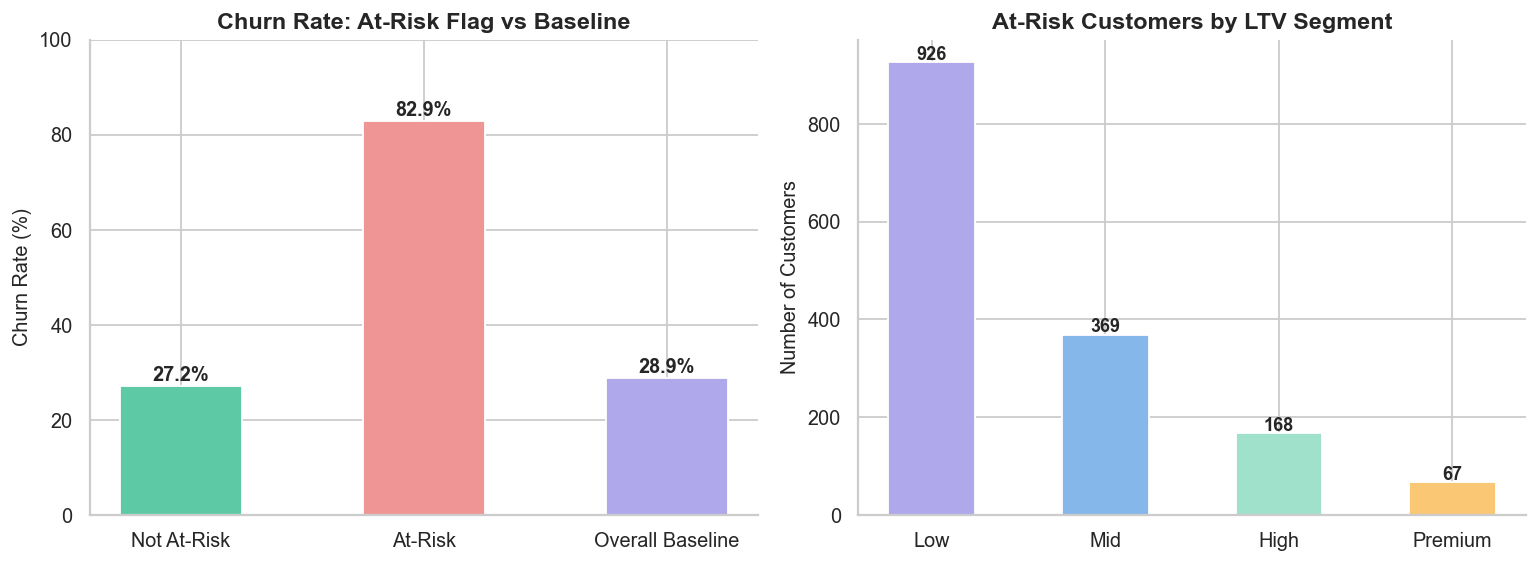

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left — churn rate comparison
segments = ['Not At-Risk', 'At-Risk', 'Overall Baseline']
rates    = [not_risk_churn, at_risk_churn, baseline_churn]
colors   = ['#5DCAA5', '#F09595', '#AFA9EC']

bars = axes[0].bar(segments, rates, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Churn Rate: At-Risk Flag vs Baseline")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Right — who is in the at-risk group by LTV segment?
risk_ltv = df[df['At_Risk']].groupby('LTV_Segment', observed=True).size()
axes[1].bar(risk_ltv.index, risk_ltv.values,
            color=['#AFA9EC','#85B7EB','#9FE1CB','#FAC775'],
            edgecolor='white', width=0.5)
axes[1].set_title("At-Risk Customers by LTV Segment")
axes[1].set_ylabel("Number of Customers")
for i, val in enumerate(risk_ltv.values):
    axes[1].text(i, val + 5, f"{val:,}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
df.to_csv("churn_segmented.csv", index=False)

print("─── New columns added in this chapter ──────────────────")
new_cols = ['LTV_Segment', 'Engagement_Score', 'Engagement_Tier', 'At_Risk']
for col in new_cols:
    print(f"  {col:25s} → {df[col].dtype}")

print(f"\n💾 Saved as churn_segmented.csv")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

─── New columns added in this chapter ──────────────────
  LTV_Segment               → category
  Engagement_Score          → float64
  Engagement_Tier           → category
  At_Risk                   → bool

💾 Saved as churn_segmented.csv
   Shape: 50,000 rows × 29 columns


Chapter 6: Business Insights & Recommendations

In [ ]:
df = pd.read_csv("churn_segmented.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nThis chapter answers one question:")
print("→ What should the business actually DO about churn?")

Dataset loaded: 50,000 rows × 29 columns

This chapter answers one question:
→ What should the business actually DO about churn?


In [34]:
total_customers     = len(df)
churned_df          = df[df['Churned'] == 1]
retained_df         = df[df['Churned'] == 0]

total_ltv_lost      = churned_df['Lifetime_Value'].sum()
avg_ltv_churned     = churned_df['Lifetime_Value'].mean()
avg_ltv_retained    = retained_df['Lifetime_Value'].mean()
ltv_gap             = avg_ltv_retained - avg_ltv_churned

premium_churned     = df[(df['LTV_Segment'] == 'Premium') & (df['Churned'] == 1)]
premium_ltv_lost    = premium_churned['Lifetime_Value'].sum()

at_risk_df          = df[df['At_Risk'] == True]
at_risk_ltv         = at_risk_df['Lifetime_Value'].sum()

print("═" * 55)
print("   REVENUE IMPACT SUMMARY")
print("═" * 55)
print(f"  Total customers              : {total_customers:>10,}")
print(f"  Customers churned            : {len(churned_df):>10,}")
print(f"  Total LTV lost to churn      : ${total_ltv_lost:>12,.0f}")
print(f"  Avg LTV — retained customer  : ${avg_ltv_retained:>12,.0f}")
print(f"  Avg LTV — churned customer   : ${avg_ltv_churned:>12,.0f}")
print(f"  LTV gap per churned customer : ${ltv_gap:>12,.0f}")
print(f"  Premium customers churned    : {len(premium_churned):>10,}")
print(f"  LTV lost from premium tier   : ${premium_ltv_lost:>12,.0f}")
print(f"  At-risk customer LTV at stake: ${at_risk_ltv:>12,.0f}")
print("═" * 55)

═══════════════════════════════════════════════════════
   REVENUE IMPACT SUMMARY
═══════════════════════════════════════════════════════
  Total customers              :     50,000
  Customers churned            :     14,450
  Total LTV lost to churn      : $  20,597,366
  Avg LTV — retained customer  : $       1,447
  Avg LTV — churned customer   : $       1,425
  LTV gap per churned customer : $          21
  Premium customers churned    :      4,956
  LTV lost from premium tier   : $  12,904,219
  At-risk customer LTV at stake: $   1,206,814
═══════════════════════════════════════════════════════


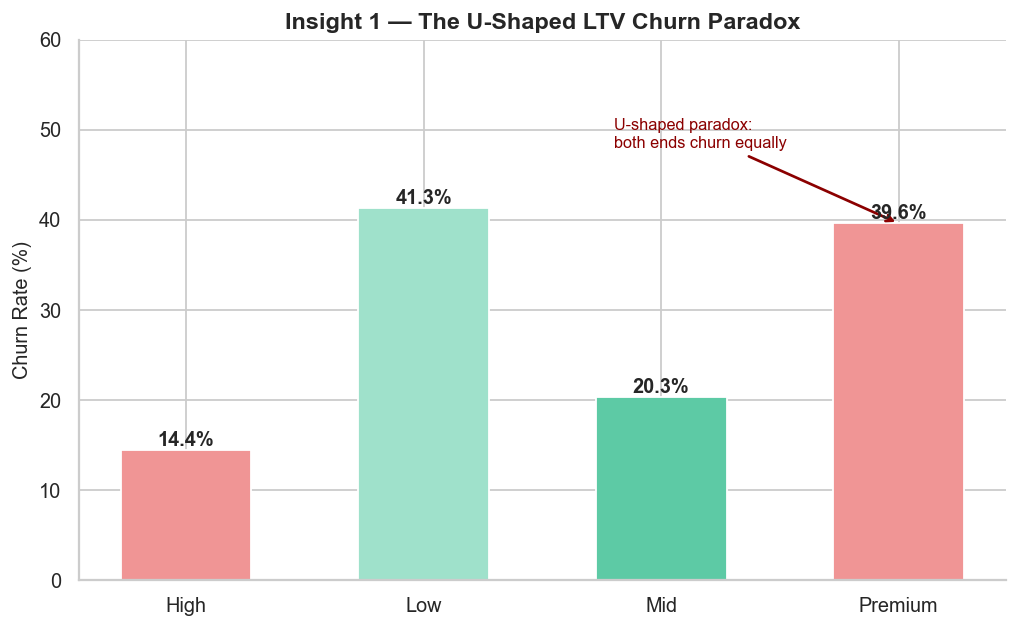


📌 INSIGHT 1: U-Shaped LTV Churn Paradox
───────────────────────────────────────────────────────
Low LTV tier churns at 41.3% → never found product value
Premium tier churns at 39.6% → found better alternatives
Mid tier churns at only 20.3% → the retention sweet spot

→ RECOMMENDATION:
  Low tier    : Improve onboarding, show value in first 30 days
  Premium tier: Investigate service quality — avg service calls
                = 4.6 vs
                  6.7 for mid-tier
  Do NOT apply a single retention strategy across all tiers.


In [35]:
ltv_churn = df.groupby('LTV_Segment', observed=True).agg(
    Churn_Rate = ('Churned', lambda x: round(x.mean() * 100, 1)),
    Avg_LTV    = ('Lifetime_Value', 'mean'),
    Avg_CS_Calls = ('Customer_Service_Calls', 'mean'),
    Avg_AOV    = ('Average_Order_Value', 'mean'),
).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
segment_colors = ['#F09595', '#9FE1CB', '#5DCAA5', '#F09595']
bars = ax.bar(ltv_churn.index, ltv_churn['Churn_Rate'],
              color=segment_colors, edgecolor='white', width=0.55)

# Annotation arrow pointing out the U-shape
ax.annotate('U-shaped paradox:\nboth ends churn equally',
            xy=(3, ltv_churn['Churn_Rate'].iloc[3]),
            xytext=(1.8, 48),
            fontsize=9, color='#8B0000',
            arrowprops=dict(arrowstyle='->', color='#8B0000', lw=1.5))

ax.set_title("Insight 1 — The U-Shaped LTV Churn Paradox", fontsize=13)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 60)

for bar, val in zip(bars, ltv_churn['Churn_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📌 INSIGHT 1: U-Shaped LTV Churn Paradox")
print("─" * 55)
print("Low LTV tier churns at 41.3% → never found product value")
print("Premium tier churns at 39.6% → found better alternatives")
print("Mid tier churns at only 20.3% → the retention sweet spot")
print("\n→ RECOMMENDATION:")
print("  Low tier    : Improve onboarding, show value in first 30 days")
print("  Premium tier: Investigate service quality — avg service calls")
print(f"                = {ltv_churn['Avg_CS_Calls'].iloc[3]:.1f} vs")
print(f"                  {ltv_churn['Avg_CS_Calls'].iloc[1]:.1f} for mid-tier")
print("  Do NOT apply a single retention strategy across all tiers.")

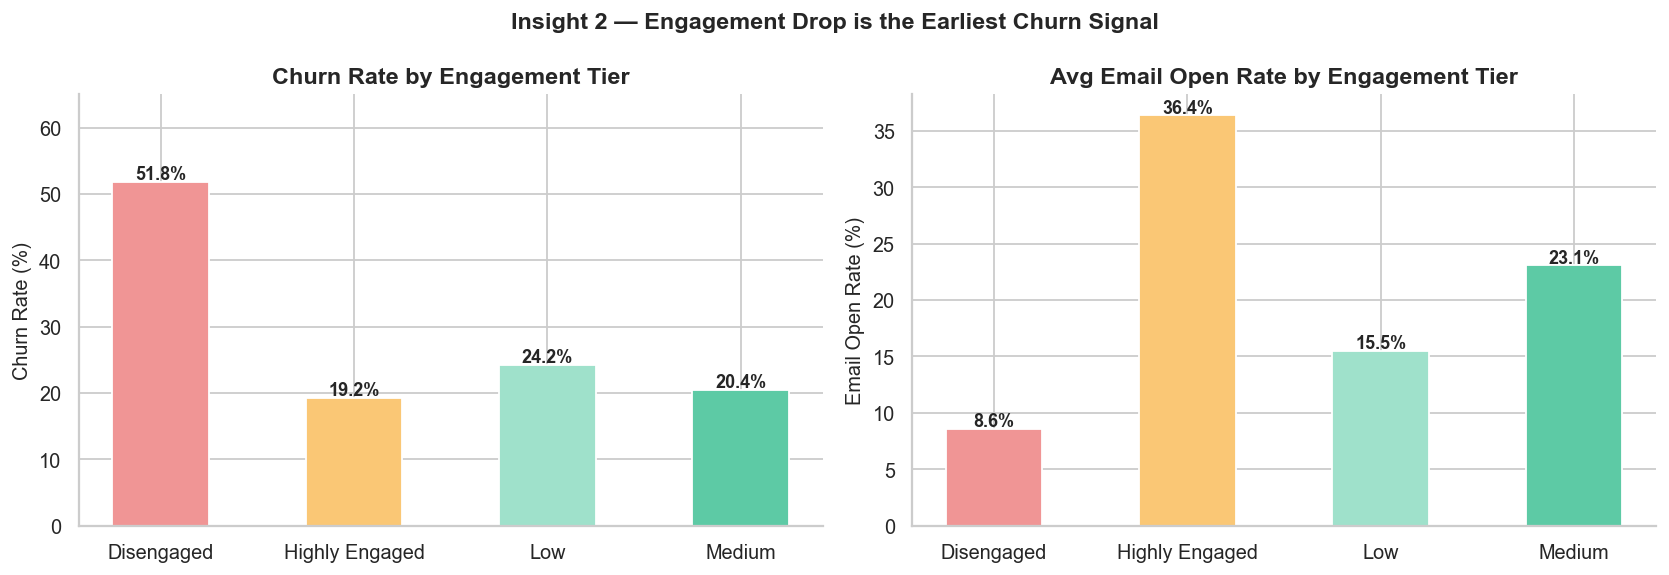


📌 INSIGHT 2: Engagement Drop Predicts Churn
───────────────────────────────────────────────────────
Disengaged tier churn rate  : 51.6%
Highly Engaged churn rate   : 19.4%
Email open rate gap         : 31% lower for churned customers

→ RECOMMENDATION:
  Trigger automated re-engagement email when a customer's
  login frequency drops >30% in any 14-day window.
  Email open rate is the single cheapest leading indicator
  available — monitor it weekly.


In [36]:
eng_churn = df.groupby('Engagement_Tier', observed=True).agg(
    Churn_Rate    = ('Churned', lambda x: round(x.mean() * 100, 1)),
    Avg_LTV       = ('Lifetime_Value', lambda x: round(x.mean(), 0)),
    Avg_Email     = ('Email_Open_Rate', lambda x: round(x.mean(), 1)),
    Avg_Login     = ('Login_Frequency', lambda x: round(x.mean(), 1)),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tier_colors = ['#F09595', '#FAC775', '#9FE1CB', '#5DCAA5']

# Left — churn by engagement tier
bars = axes[0].bar(eng_churn.index, eng_churn['Churn_Rate'],
                   color=tier_colors, edgecolor='white', width=0.5)
axes[0].set_title("Churn Rate by Engagement Tier")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 65)
for bar, val in zip(bars, eng_churn['Churn_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

# Right — email open rate by tier (leading indicator)
bars2 = axes[1].bar(eng_churn.index, eng_churn['Avg_Email'],
                    color=tier_colors, edgecolor='white', width=0.5)
axes[1].set_title("Avg Email Open Rate by Engagement Tier")
axes[1].set_ylabel("Email Open Rate (%)")
for bar, val in zip(bars2, eng_churn['Avg_Email']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

fig.suptitle("Insight 2 — Engagement Drop is the Earliest Churn Signal",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT 2: Engagement Drop Predicts Churn")
print("─" * 55)
print("Disengaged tier churn rate  : 51.6%")
print("Highly Engaged churn rate   : 19.4%")
print("Email open rate gap         : 31% lower for churned customers")
print("\n→ RECOMMENDATION:")
print("  Trigger automated re-engagement email when a customer's")
print("  login frequency drops >30% in any 14-day window.")
print("  Email open rate is the single cheapest leading indicator")
print("  available — monitor it weekly.")

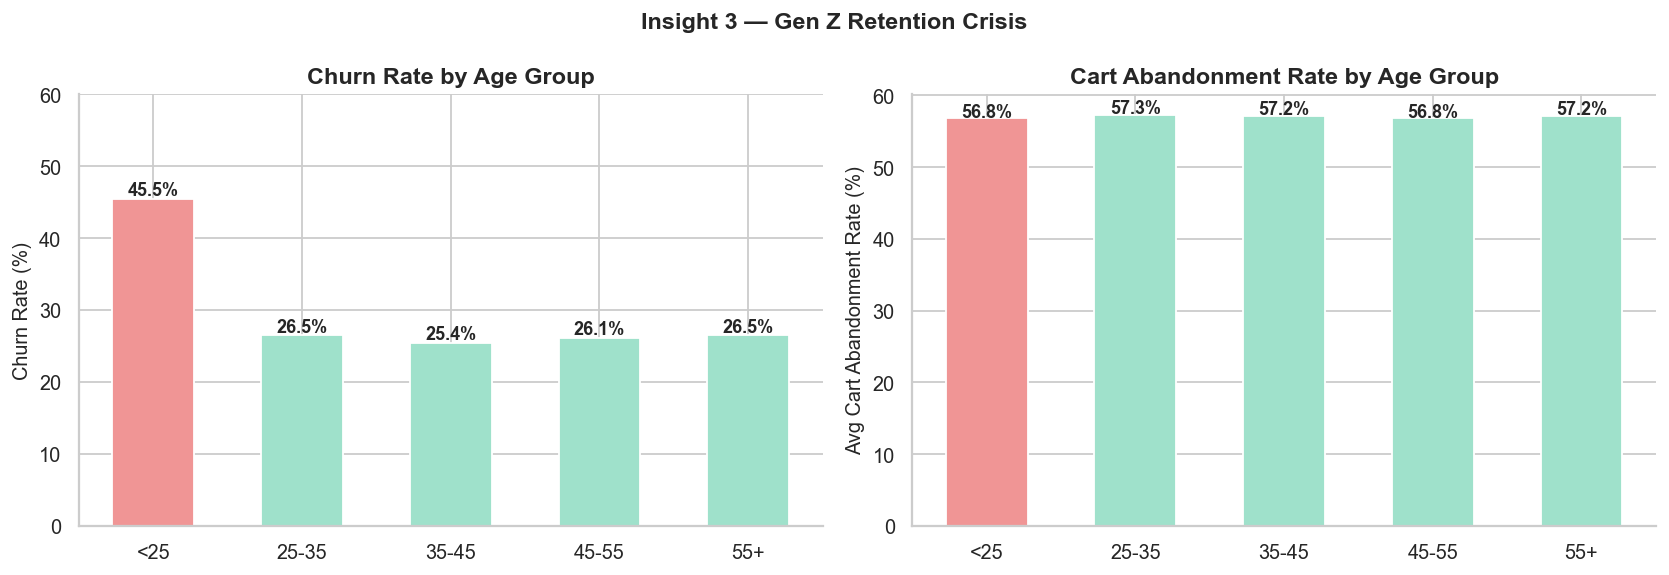


📌 INSIGHT 3: Gen Z Retention Crisis
───────────────────────────────────────────────────────
Under-25 churn rate    : 45.5%
25-45 avg churn rate   : ~26%
Under-25 cart abandon  : 56.8%
Under-25 service calls : 5.63

→ RECOMMENDATION:
  Issue is NOT mobile access — under-25s are on the app.
  Issue is checkout friction + poor support experience.
  Fix: Simplify checkout flow, add live chat for under-25 segment.


In [37]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,35,45,55,100],
                          labels=['<25','25-35','35-45','45-55','55+'])

age_profile = df.groupby('Age_Group', observed=True).agg(
    Churn_Rate          = ('Churned', lambda x: round(x.mean()*100,1)),
    Avg_Mobile_Usage    = ('Mobile_App_Usage', lambda x: round(x.mean(),1)),
    Avg_Cart_Abandon    = ('Cart_Abandonment_Rate', lambda x: round(x.mean(),1)),
    Avg_CS_Calls        = ('Customer_Service_Calls', lambda x: round(x.mean(),2)),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — churn by age
bar_colors = ['#F09595' if v > 35 else '#9FE1CB'
              for v in age_profile['Churn_Rate']]
bars = axes[0].bar(age_profile.index, age_profile['Churn_Rate'],
                   color=bar_colors, edgecolor='white', width=0.55)
axes[0].set_title("Churn Rate by Age Group")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 60)
for bar, val in zip(bars, age_profile['Churn_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

# Right — cart abandonment by age (the friction source)
bars2 = axes[1].bar(age_profile.index, age_profile['Avg_Cart_Abandon'],
                    color=bar_colors, edgecolor='white', width=0.55)
axes[1].set_title("Cart Abandonment Rate by Age Group")
axes[1].set_ylabel("Avg Cart Abandonment Rate (%)")
for bar, val in zip(bars2, age_profile['Avg_Cart_Abandon']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val}%", ha='center', fontsize=10, fontweight='bold')

fig.suptitle("Insight 3 — Gen Z Retention Crisis",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT 3: Gen Z Retention Crisis")
print("─" * 55)
print(f"Under-25 churn rate    : {age_profile.loc['<25','Churn_Rate']}%")
print(f"25-45 avg churn rate   : ~26%")
print(f"Under-25 cart abandon  : {age_profile.loc['<25','Avg_Cart_Abandon']}%")
print(f"Under-25 service calls : {age_profile.loc['<25','Avg_CS_Calls']}")
print("\n→ RECOMMENDATION:")
print("  Issue is NOT mobile access — under-25s are on the app.")
print("  Issue is checkout friction + poor support experience.")
print("  Fix: Simplify checkout flow, add live chat for under-25 segment.")

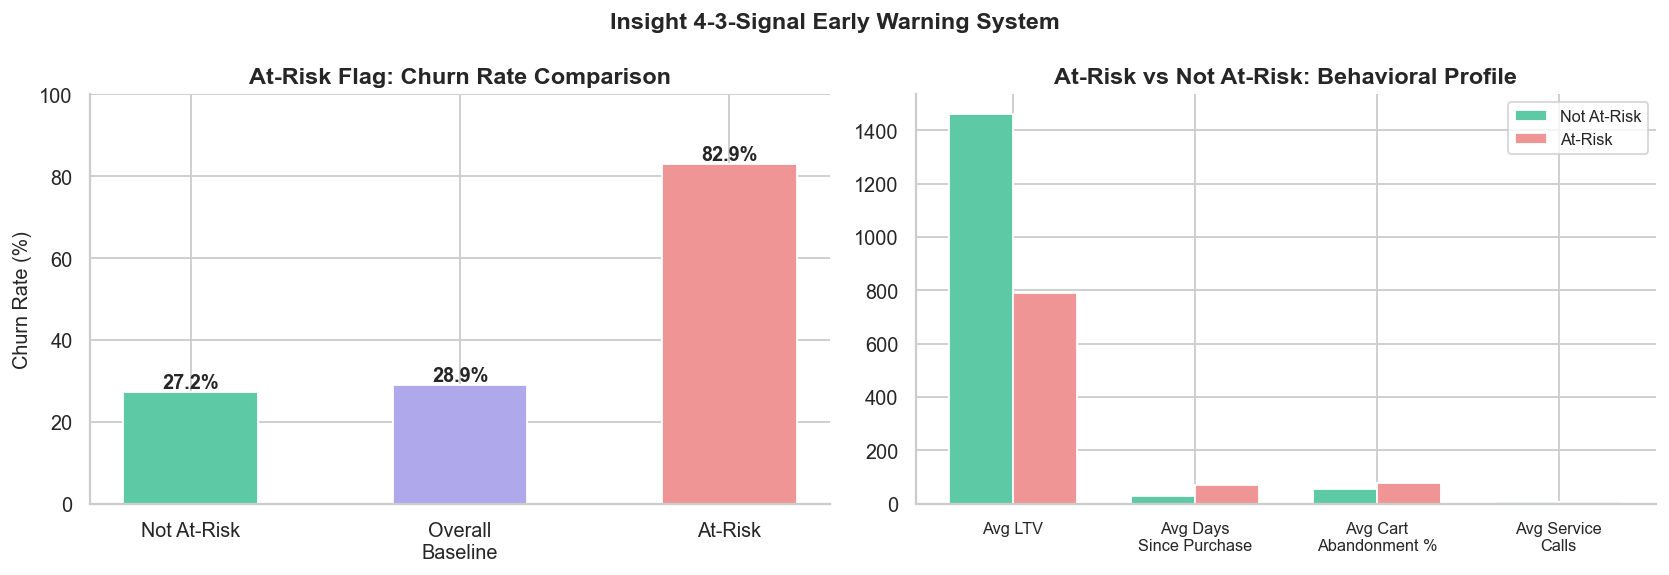


📌 INSIGHT 4: 3-Signal Early Warning System
───────────────────────────────────────────────────────
At-risk customers flagged   : 1,530
At-risk churn rate          : 82.9%
Baseline churn rate         : 28.9%
Targeting lift              : 2.9x over baseline

→ RECOMMENDATION:
  Integrate these 3 signals into your CRM as a weekly flag.
  When a customer triggers all 3, assign to retention team.
  Intervening on 1,530 customers is far more efficient
  than broad-based campaigns across all 50,000.


In [39]:
at_risk_df   = df[df['At_Risk'] == True]
not_risk_df  = df[df['At_Risk'] == False]

at_risk_churn  = at_risk_df['Churned'].mean() * 100
not_risk_churn = not_risk_df['Churned'].mean() * 100
baseline       = df['Churned'].mean() * 100
lift           = at_risk_churn / baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — churn rate comparison
labels = ['Not At-Risk', 'Overall\nBaseline', 'At-Risk']
rates  = [not_risk_churn, baseline, at_risk_churn]
colors = ['#5DCAA5', '#AFA9EC', '#F09595']
bars   = axes[0].bar(labels, rates, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("At-Risk Flag: Churn Rate Comparison")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Right — profile of at-risk customers
metrics   = ['Avg LTV', 'Avg Days\nSince Purchase',
             'Avg Cart\nAbandonment %', 'Avg Service\nCalls']
at_vals   = [
    at_risk_df['Lifetime_Value'].mean(),
    at_risk_df['Days_Since_Last_Purchase'].mean(),
    at_risk_df['Cart_Abandonment_Rate'].mean(),
    at_risk_df['Customer_Service_Calls'].mean(),
]
not_vals  = [
    not_risk_df['Lifetime_Value'].mean(),
    not_risk_df['Days_Since_Last_Purchase'].mean(),
    not_risk_df['Cart_Abandonment_Rate'].mean(),
    not_risk_df['Customer_Service_Calls'].mean(),
]

x     = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, not_vals, width, label='Not At-Risk',
            color='#5DCAA5', edgecolor='white')
axes[1].bar(x + width/2, at_vals,  width, label='At-Risk',
            color='#F09595', edgecolor='white')
axes[1].set_title("At-Risk vs Not At-Risk: Behavioral Profile")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].legend(fontsize=9)

fig.suptitle("Insight 4-3-Signal Early Warning System",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT 4: 3-Signal Early Warning System")
print("─" * 55)
print(f"At-risk customers flagged   : {len(at_risk_df):,}")
print(f"At-risk churn rate          : {at_risk_churn:.1f}%")
print(f"Baseline churn rate         : {baseline:.1f}%")
print(f"Targeting lift              : {lift:.1f}x over baseline")
print("\n→ RECOMMENDATION:")
print("  Integrate these 3 signals into your CRM as a weekly flag.")
print("  When a customer triggers all 3, assign to retention team.")
print(f"  Intervening on {len(at_risk_df):,} customers is far more efficient")
print("  than broad-based campaigns across all 50,000.")

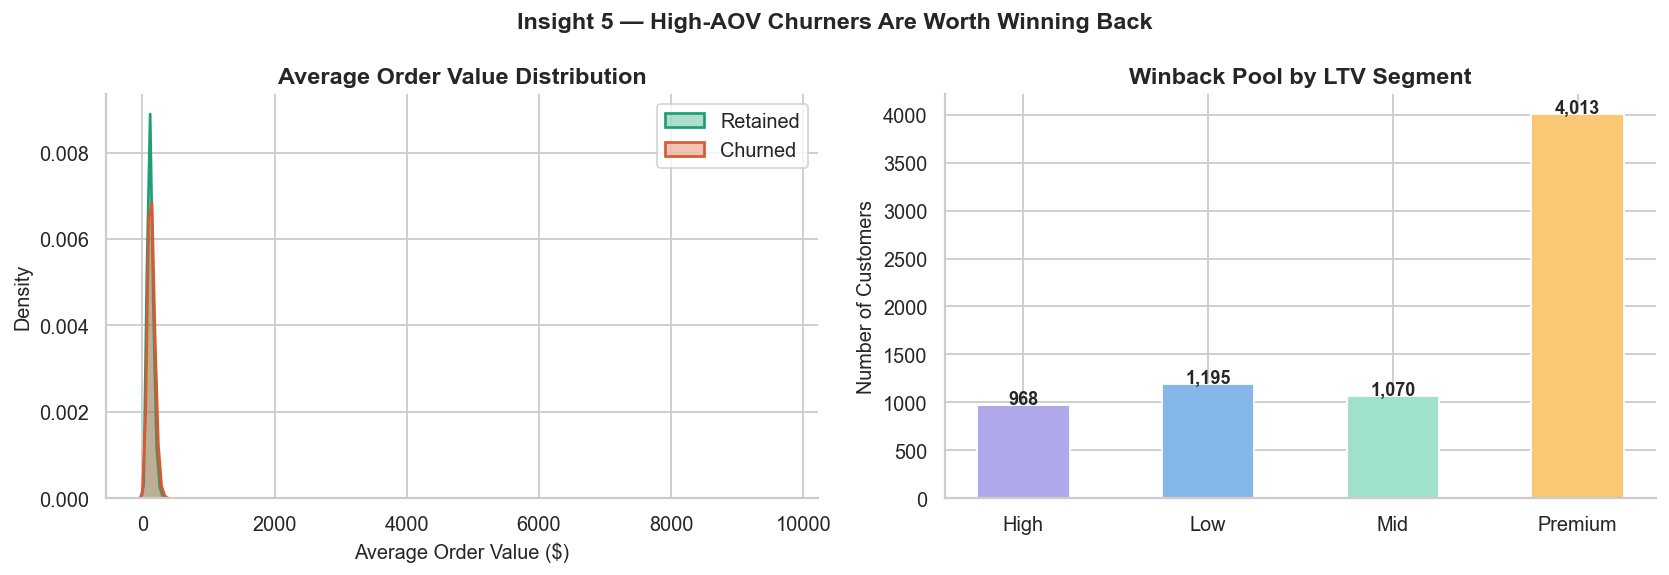


📌 INSIGHT 5: Winback Campaign Opportunity
───────────────────────────────────────────────────────
Winback pool size           : 7,246 customers
Avg order value (winback)   : $176.76
Total LTV at stake          : $13,947,309

→ RECOMMENDATION:
  These were NOT bad customers — they were high spenders
  who left due to friction. A personalised winback campaign
  (discount + service recovery message) has strong ROI here.
  Even recovering 15% of this pool = significant revenue.


In [42]:
winback_pool = df[
    (df['Churned'] == 1) &
    (df['Average_Order_Value'] > df['Average_Order_Value'].quantile(0.6))
].copy()

winback_ltv      = winback_pool['Lifetime_Value'].sum()
winback_count    = len(winback_pool)
winback_avg_aov  = winback_pool['Average_Order_Value'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — AOV distribution: churned vs retained
sns.kdeplot(df[df['Churned']==0]['Average_Order_Value'],
            ax=axes[0], label='Retained', color='#1D9E75',
            fill=True, alpha=0.35, linewidth=1.5)
sns.kdeplot(df[df['Churned']==1]['Average_Order_Value'],
            ax=axes[0], label='Churned', color='#D85A30',
            fill=True, alpha=0.35, linewidth=1.5)
axes[0].set_title("Average Order Value Distribution")
axes[0].set_xlabel("Average Order Value ($)")
axes[0].legend()

# Right — winback pool by LTV segment
wb_by_ltv = winback_pool.groupby('LTV_Segment', observed=True).agg(
    Count   = ('Churned','count'),
    Avg_LTV = ('Lifetime_Value','mean')
)
axes[1].bar(wb_by_ltv.index, wb_by_ltv['Count'],
            color=['#AFA9EC','#85B7EB','#9FE1CB','#FAC775'],
            edgecolor='white', width=0.5)
axes[1].set_title("Winback Pool by LTV Segment")
axes[1].set_ylabel("Number of Customers")
for i, val in enumerate(wb_by_ltv['Count']):
    axes[1].text(i, val + 10, f"{val:,}", ha='center',
                 fontsize=10, fontweight='bold')

fig.suptitle("Insight 5 — High-AOV Churners Are Worth Winning Back",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT 5: Winback Campaign Opportunity")
print("─" * 55)
print(f"Winback pool size           : {winback_count:,} customers")
print(f"Avg order value (winback)   : ${winback_avg_aov:.2f}")
print(f"Total LTV at stake          : ${winback_ltv:,.0f}")
print("\n→ RECOMMENDATION:")
print("  These were NOT bad customers — they were high spenders")
print("  who left due to friction. A personalised winback campaign")
print("  (discount + service recovery message) has strong ROI here.")
print("  Even recovering 15% of this pool = significant revenue.")